In [1]:
%matplotlib inline
import inspect
import math
import re

import matplotlib.pyplot as plt
import numpy as np
import torch
import warp as wp

from warpSPHCore import *
from warpSPHCore.util import generateNeighborTestData

# Initialize Warp
wp.config.verify_autograd_array_access = False
wp.config.verbose = False
wp.init()


Warp 1.16.0 initialized:
   CUDA Toolkit 12.9, Driver 13.3
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 6000 Blackwell Workstation Edition" (95 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.16.0


Warp DeprecationWarning: warp.config.verbose is deprecated; use warp.config.log_level = warp.LOG_DEBUG instead.


In [2]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
targetNumNeighbors = 50
nx = 128
dim = 1
numParticles = nx ** dim

warpOnly = False
periodic = True
field_mode = "periodic_sinusoidal"  # "linear" or "periodic_sinusoidal"
mask_edge_particles = True  # used for linear fields to hide the periodic jump at the boundaries
jitter = 0.05
linear_slope_x = 5.0
linear_slope_y = 0.0

kernel = KernelFunctions.Wendland2
supportMode = SupportScheme.Gather

markerSize = 8 if warpOnly else 2
gridVisualization = False
gridResolution = 128
dx = 2.0 / nx


In [3]:
from typing import Any

from warpSPHCore.util.cast import _get_warp_matrix_dtype, _get_warp_vector_dtype

@wp.kernel
def computeKernelValues(
    pos: wp.array(dtype=Any),
    kernelValues: wp.array(dtype=Any),
    kernelGradients: wp.array(dtype=Any),
    kernelHessians: wp.array(dtype=Any),
    numParticles: int,
    supportRadius: wp.float32,
    kernelProperties: kernelState,
    domainProperties: domainData,
):
    tid = wp.tid()
    if tid < numParticles:
        p = pos[tid]
        p = p * 0.0
        r = supportRadius
        q = 0.0
        for j in range(numParticles):
            if j != tid:
                diff = p - pos[j]
                kernelValues[j] = sphKernel(p, pos[j], supportRadius, supportRadius, kernelProperties, domainProperties)
                kernelGradients[j] = sphKernelGradient(p, pos[j], supportRadius, supportRadius, kernelProperties, domainProperties)
                kernelHessians[j] = sphKernelHessian(p, pos[j], supportRadius, supportRadius, kernelProperties, domainProperties)

In [ ]:
domain = domainData()
domain.domainMin = wp.from_torch(torch.tensor([-1.0] * dim, device=device))
domain.domainMax = wp.from_torch(torch.tensor([1.0] * dim, device=device))
domain.periodicity = wp.from_torch(torch.tensor([periodic] * dim, device=device))
wp_device = domain.domainMin.device
domain.dim = dim

kernelProps = kernelState()
kernelProps.kernelFunction = KernelFunctions.Wendland2.value
kernelProps.supportMode = SupportScheme.Gather.value


In [ ]:
numParticles = 1023
kernelValues = wp.zeros(numParticles, dtype=wp.float32, device=wp_device)
kernelGradients = wp.zeros(numParticles, dtype=_get_warp_vector_dtype(dim, torch.float32), device=wp_device)
kernelHessians = wp.zeros(numParticles, dtype=_get_warp_matrix_dtype(dim, dim, torch.float32), device=wp_device)


positions = np.linspace(-1.0, 1.0, numParticles)
pos = castTorchToWarpAsBuiltins(torch.tensor(positions, device=device, dtype=torch.float32).reshape(-1, 1))
supportRadius = 1.0

wp.launch(computeKernelValues, dim=1, inputs=[pos, kernelValues, kernelGradients, kernelHessians, numParticles, supportRadius, kernelProps, domain])

Module __main__ 2eefab8 load on device 'cuda:0' took 1605.20 ms  (compiled)


Text(0.5, 1.0, 'Kernel Hessians (xx component)')

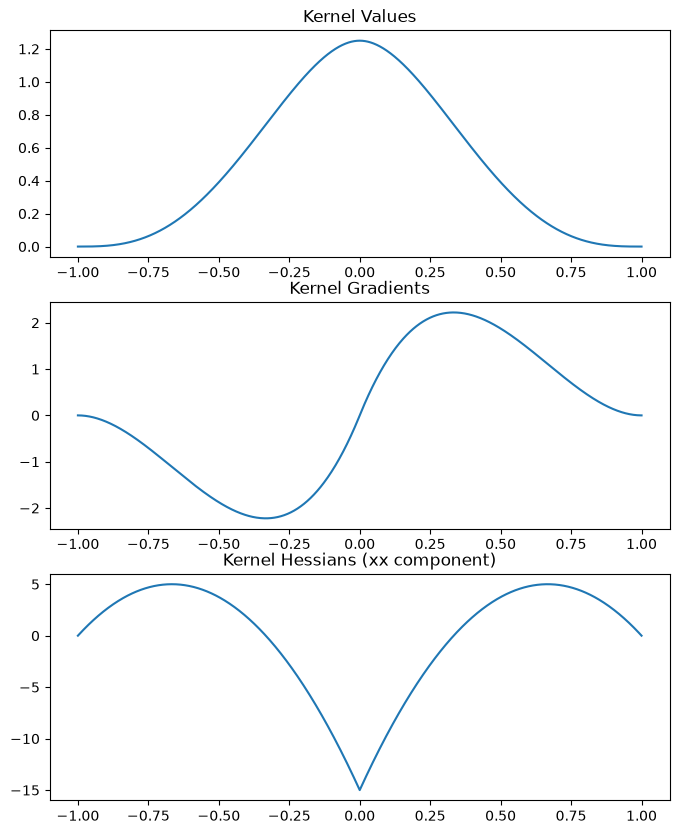

In [6]:
fig, ax = plt.subplots(3,1, figsize=(8, 10), squeeze=False)

ax[0, 0].plot(positions, kernelValues.numpy(), label="Kernel Values")
ax[0, 0].set_title("Kernel Values")

ax[1, 0].plot(positions, kernelGradients.numpy(), label="Kernel Gradients")
ax[1, 0].set_title("Kernel Gradients")

ax[2, 0].plot(positions, kernelHessians.numpy()[:, 0, 0], label="Kernel Hessians")
ax[2, 0].set_title("Kernel Hessians (xx component)")


In [12]:

print(f"Kernel Values: {kernelValues.numpy()[len(kernelValues)//2-1]} -> {kernelValues.numpy()[len(kernelValues)//2]} -> {kernelValues.numpy()[len(kernelValues)//2+1]}")
print(f"Kernel Gradients: {kernelGradients.numpy()[len(kernelGradients)//2-1]} -> {kernelGradients.numpy()[len(kernelGradients)//2]} -> {kernelGradients.numpy()[len(kernelGradients)//2+1]}")
print(f"Kernel Hessians: {kernelHessians.numpy()[len(kernelHessians)//2-1]} -> {kernelHessians.numpy()[len(kernelHessians)//2]} -> {kernelHessians.numpy()[len(kernelHessians)//2+1]}")

Kernel Values: 1.2499712705612183 -> 1.25 -> 1.2499712705612183
Kernel Gradients: [-0.02923932] -> [-0.] -> [0.02923932]
Kernel Hessians: [[-14.882756]] -> [[-15.]] -> [[-14.882756]]
